# Modelo GPR

In [10]:
import os
import numpy as np
root_dir = r"../Spectra/FinalSamples"
dir_wln = os.path.join(root_dir, f"Level2/LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"Level2/LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")
dir_concentraciones = os.path.join(root_dir, f"concentraciones.txt")
concentraciones = np.genfromtxt(dir_concentraciones, skip_header=1) 

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


In [12]:
# Construimos X (samples × features) y y (samples × targets)
X = all_Spectra.T     # shape = (n_samples, n_wavelengths)
y = concentraciones                   # shape = (n_samples, 2)

In [13]:
# ————————————— Split train / test —————————————
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=0
)

# ————— Escalado de X e y —————
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
# no escalamos y_test aún; lo usaremos para métricas en original
# y_test_scaled = y_scaler.transform(y_test)

In [14]:
# ————— Kernel GPR —————
kernel = ConstantKernel(1.0, (1e-5, 1e3)) * \
         RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e3)) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1))

n_components = y_train.shape[1]  # 2

# Prealocamos arrays para predicciones
y_pred_train = np.zeros_like(y_train)
y_std_train  = np.zeros_like(y_train)
y_pred_test  = np.zeros_like(y_test)
y_std_test   = np.zeros_like(y_test)

# ————— Ajustamos un GPR independiente por elemento —————
models = []
for j in range(n_components):
    gp = GaussianProcessRegressor(kernel=kernel,
                                  normalize_y=False,
                                  random_state=0)
    # fit en datos escalados
    gp.fit(X_train, y_train_scaled[:, j])

    # predicción en train (escalada)
    y_tr_s, std_tr_s = gp.predict(X_train, return_std=True)
    # inversa: recuperamos unidades originales
    y_pred_train[:, j] = y_scaler.inverse_transform(
        np.vstack([y_tr_s, np.zeros_like(y_tr_s)]).T
    )[:, j]
    y_std_train[:, j] = std_tr_s * y_scaler.scale_[j]

    # predicción en test (escalada)
    y_te_s, std_te_s = gp.predict(X_test, return_std=True)
    y_pred_test[:, j] = y_scaler.inverse_transform(
        np.vstack([y_te_s, np.zeros_like(y_te_s)]).T
    )[:, j]
    y_std_test[:, j] = std_te_s * y_scaler.scale_[j]

    models.append(gp)

In [15]:
# ————— Cálculo de métricas —————
metrics = {}
labels = ['Na','Mg']
for j, lbl in enumerate(labels):
    r2_tr   = r2_score(y_train[:, j], y_pred_train[:, j])
    rmse_tr = np.sqrt(mean_squared_error(y_train[:, j], y_pred_train[:, j]))
    r2_te   = r2_score(y_test[:,  j], y_pred_test[:,  j])
    rmse_te = np.sqrt(mean_squared_error(y_test[:,  j], y_pred_test[:,  j]))
    metrics[lbl] = (r2_tr, rmse_tr, r2_te, rmse_te)


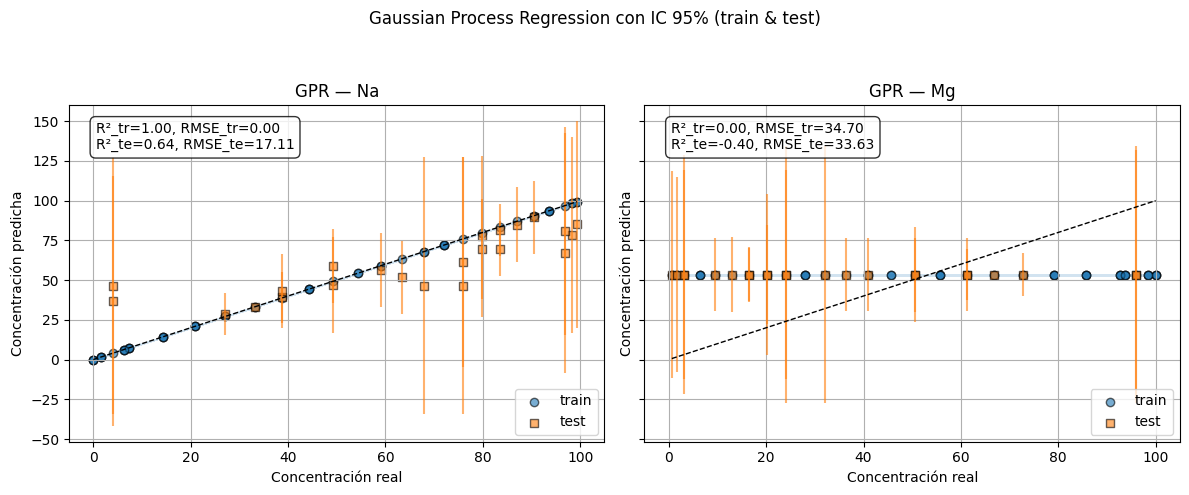

In [16]:
# ————— Gráfica con IC 95% —————
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

for ax, j, lbl in zip(axes, range(n_components), labels):
    # train
    ax.scatter(y_train[:, j], y_pred_train[:, j],
               c='C0', marker='o', edgecolor='k', alpha=0.6, label='train')
    ax.fill_between(
        y_train[:, j],
        y_pred_train[:, j] - 1.96*y_std_train[:, j],
        y_pred_train[:, j] + 1.96*y_std_train[:, j],
        color='C0', alpha=0.2
    )
    # test
    ax.scatter(y_test[:, j], y_pred_test[:, j],
               c='C1', marker='s', edgecolor='k', alpha=0.6, label='test')
    ax.errorbar(
        y_test[:, j], y_pred_test[:, j],
        yerr=1.96*y_std_test[:, j],
        fmt='none', ecolor='C1', alpha=0.6
    )

    mn = min(y[:, j].min(), y_pred_train[:, j].min(), y_pred_test[:, j].min())
    mx = max(y[:, j].max(), y_pred_train[:, j].max(), y_pred_test[:, j].max())
    ax.plot([mn,mx], [mn,mx], 'k--', lw=1)

    # caja de texto con métricas
    r2_tr, rmse_tr, r2_te, rmse_te = metrics[lbl]
    txt = (f"R²_tr={r2_tr:.2f}, RMSE_tr={rmse_tr:.2f}\n"
           f"R²_te={r2_te:.2f}, RMSE_te={rmse_te:.2f}")
    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

    ax.set_xlabel("Concentración real")
    ax.set_ylabel("Concentración predicha")
    ax.set_title(f"GPR — {lbl}")
    ax.legend(loc='lower right')
    ax.grid(True)

fig.suptitle("Gaussian Process Regression con IC 95% (train & test)")
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()